# Demo of Polyply integration tools from SwiftPol

- Build a PLGA SwiftPol ensemble
- Export to [Polyply](https://github.com/marrink-lab/polyply_1.0) input files

Prerequisites:
- Polyply
- GROMACS (including a steepest descent minimisation .mdp file)
- OpenFF toolkit
- OpenFF interchange

In [1]:
# Print SwiftPol Version
from swiftpol.__version__ import __version__
__version__

LICENSE: Could not open license file "oe_license.txt" in local directory
LICENSE: N.B. OE_LICENSE environment variable is not set
LICENSE: N.B. OE_DIR environment variable is not set
LICENSE: No product keys!
LICENSE: No product keys!
LICENSE: No product keys!
The OpenEye Toolkits are found to be installed but not licensed and therefore will not be used.
The OpenEye Toolkits require a (free for academics) license, see https://docs.eyesopen.com/toolkits/python/quickstart-python/license.html
LICENSE: No product keys!
The OpenEye Toolkits are found to be installed but not licensed and therefore will not be used.
The OpenEye Toolkits require a (free for academics) license, see https://docs.eyesopen.com/toolkits/python/quickstart-python/license.html


'0.1.4'

In [2]:
# Build a PLGA system
# Note: This polymer system is small, to facilitate a fast workflow demo, therefore some parameters (chain length, residual monomer) may not be close to input
# PLGA is composed of diblock lactide and glycolide monomers. To recreate this, set diblock=True
from swiftpol import build
polymer = build.polymer_system_from_PDI(monomer_list=['O[C@H](C)C(=O)O[I]', 'OCC(=O)O[I]'], 
                                        reaction='[C:1][O:2][H:3].[I:4][O:5][C:6]>>[C:1][O:2][C:6].[H:3][O:5][I:4]',
                                        length_target=10, 
                                        terminals='ester', 
                                        num_chains=10,
                                        perc_A_target=74.3,
                                        PDI_target=1.7,
                                        blockiness_target=[1.0, 'B'], 
                                        copolymer=True,
                                        diblock=True,
                                        acceptance=20)

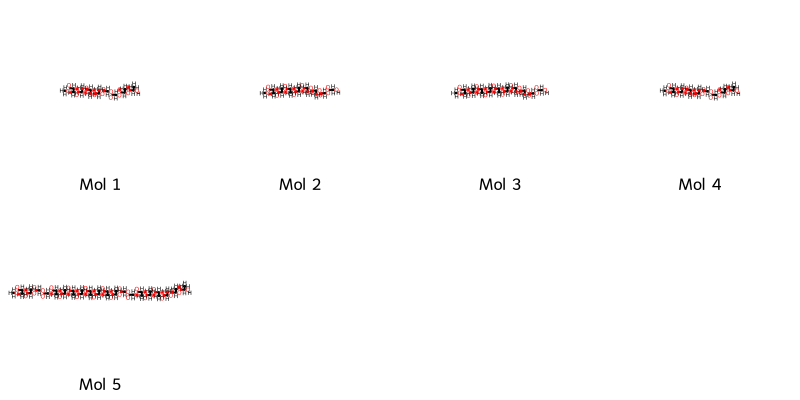

In [3]:
# Generate a grid image of the molecules
from rdkit.Chem import Draw
Draw.MolsToGridImage(
    polymer.chain_rdkit,
    molsPerRow=4,  # Number of molecules per row
    subImgSize=(200, 200),  # Size of each molecule image
    legends=[f"Mol {i+1}" for i in range(len(polymer.chain_rdkit))]  # Optional legends
)

In [4]:
# Generate conformers and inspect first chain in 3D (requires nglview)
polymer.generate_conformers(rough=True)
polymer.chains[0].visualize('nglview')

/Users/hannahturney/Library/CloudStorage/OneDrive-King'sCollegeLondon/Hannah/PhD/SwiftPol/swiftpol/build.py:1994: UserWarning: Rough coordinates have been generated. Any charges previously applied to the system.chains attributewill need to be reapplied.
  warn(


NGLWidget()

In [5]:
# Charge the PLGA system using OpenFF AshGC 
polymer.charge_system('AshGC')

The OpenEye Toolkits are found to be installed but not licensed and therefore will not be used.
The OpenEye Toolkits require a (free for academics) license, see https://docs.eyesopen.com/toolkits/python/quickstart-python/license.html


In [8]:
# Export to polyply input file format
# Also save the topology generated by OpenFF toolkit
topology = polymer.generate_polyply_files()

Polyply input files generated! Saved at ('swiftpol_output.gro', 'swiftpol_output.top', '0.pdb', '1.pdb')


In [ ]:
# Install polyply
# !pip install polyply
# Generate polyply input files
import subprocess
# we use a density of 1300 g/m3, which is a common value for PLGA, but this can be adjusted based on the specific system and conditions
subprocess.run(['polyply gen_coords -p swiftpol_gromacs.top -name test -dens 1300 -o swiftpol_gromacs.gro'], check=True, shell=True)
# Run energy minimization in GROMACS to relax the system
subprocess.run(['gmx', 'grompp', '-f', 'min.mdp', '-c', 'swiftpol_gromacs.gro', '-p', 'swiftpol_gromacs.top', '-o', 'em.tpr', '-maxwarn', '10'], check=True)
subprocess.run(['gmx', 'mdrun', '-deffnm', 'em'], check=True)


You can now go ahead and start the simulation in GROMACS using OpenFF parameters. To reimport the coordinates for OpenMM use, continue in this notebook

In [ ]:
import openff.unit as unit
polyply_top_path = 'em.gro'

with open(polyply_top_path, 'r') as file:
    pma_itp_content = file.readlines()

coordinates = []
for i in pma_itp_content[2:-1]:
    i_s = i.strip().split('  ')
    #Find atom  - make dict
    x = float(i_s[-3].strip())*10 
    y = float(i_s[-2].strip())*10
    z = float(i_s[-1].strip())*10
    coordinates.append([x,y,z])
coords_arr = np.array(coordinates)   
topology.set_positions(coords_arr * unit.angstrom)

You now have a variable `topology` to export to OpenMM